In [1]:
from src.loader.reader import Reader, Dataset_BigEarthNet
from src.utils.utils import load_config

In [2]:
config_path = "src/config/config.yaml"
config_dataset = load_config(config_path)

In [3]:
config_dataset['datasets']['metadata_parquet']

'/root/bigearthnet/BigEarthNet-Models/df_balanced/teste2.parquet'

In [4]:
config_dataset['datasets']['metadata_parquet'].endswith(".csv")

True

In [4]:
reader = Reader("~/storage_ds/BigEarthNet-S2",config_dataset['datasets']['metadata_parquet'])

2025-08-18 13:14:14.910 | INFO     | src.loader.reader:__init__:208 - Initializing the Reader, structuring the paths and files.
2025-08-18 13:14:15.114 | INFO     | src.loader.reader:parent_folders:262 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-18 13:14:20.945 | INFO     | src.loader.reader:_create_lookup_structures:246 - Created lookup structures for 145781 patches
2025-08-18 13:14:20.946 | INFO     | src.loader.reader:__init__:230 - None


Number of parent folders: 115
Number of total patches found it: 549488


In [49]:
reader.metadata_parquet['patch_id'].iloc[0]

'S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_72_79'

In [50]:
reader.__getitem__('S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_72_79')[1]

array(['Agro-forestry areas', 'Transitional woodland, shrub'],
      dtype=object)

In [30]:
filtered_df = reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(patch_ids_array)]

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform([filtered_df['labels']])

In [45]:
filtered_df['labels'].unique()

array(["['Agro-forestry areas' 'Broad-leaved forest']",
       "['Agro-forestry areas' 'Arable land' 'Pastures']",
       "['Agro-forestry areas' 'Arable land' 'Broad-leaved forest']", ...,
       "['Complex cultivation patterns' 'Inland wetlands'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Pastures' 'Urban fabric']",
       "['Broad-leaved forest'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Marine waters' 'Mixed forest' 'Urban fabric']",
       "['Complex cultivation patterns' 'Coniferous forest' 'Inland waters'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Transitional woodland, shrub' 'Urban fabric']"],
      dtype=object)

In [46]:
mlb.classes_

array(["['Agro-forestry areas'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Moors, heathland and sclerophyllous vegetation' 'Permanent crops']",
       "['Agro-forestry areas'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Pastures' 'Transitional woodland, shrub']",
       "['Agro-forestry areas'\n 'Land principally occupied by agriculture, with significant areas of natural vegetation'\n 'Pastures']",
       ..., "['Transitional woodland, shrub' 'Urban fabric']",
       "['Transitional woodland, shrub']", "['Urban fabric']"],
      dtype=object)

In [6]:
label_to_idx = {'Agro-forestry areas': 0,
                'Arable land': 1,
                'Beaches, dunes, sands': 2,
                'Broad-leaved forest': 3,
                'Coastal wetlands': 4,
                'Complex cultivation patterns': 5,
                'Coniferous forest': 6,
                'Industrial or commercial units': 7,
                'Inland waters': 8,
                'Inland wetlands': 9,
                'Land principally occupied by agriculture, with significant areas of natural vegetation': 10,
                'Marine waters': 11,
                'Mixed forest': 12,
                'Moors, heathland and sclerophyllous vegetation': 13,
                'Natural grassland and sparsely vegetated areas': 14,
                'Pastures': 15,
                'Permanent crops': 16,
                'Transitional woodland, shrub': 17,
                'Urban fabric': 18}

In [7]:
val_dataset = Dataset_BigEarthNet(reader=reader,
                              strip_bands=["B02", "B03", "B04"],
                              img_size=120,
                              upsample_mode='bicubic',
                              normalize=False,
                              small_fraction=0.2,
                              split_train_test='validation',
                              dict_one_hot=label_to_idx)

2025-08-18 13:14:25.723 | INFO     | src.loader.reader:__init__:465 - validation split, with length of 37385
2025-08-18 13:14:25.724 | WARNING  | src.loader.reader:__init__:473 - Small sample selected. Dataset is reduced!
2025-08-18 13:14:25.724 | INFO     | src.loader.reader:__init__:474 - validation split, with length of 7477
2025-08-18 13:14:25.724 | INFO     | src.loader.reader:__init__:488 - Bands orded by: ['B02', 'B03', 'B04']


In [8]:
train_dataset = Dataset_BigEarthNet(reader=reader,
                              strip_bands=["B02", "B03", "B04"],
                              img_size=120,
                              upsample_mode='bicubic',
                              normalize=False,
                              small_fraction=0.2,
                              split_train_test='train',
                              dict_one_hot=label_to_idx)

2025-08-18 13:14:26.839 | INFO     | src.loader.reader:__init__:465 - train split, with length of 72980
2025-08-18 13:14:26.840 | WARNING  | src.loader.reader:__init__:473 - Small sample selected. Dataset is reduced!
2025-08-18 13:14:26.840 | INFO     | src.loader.reader:__init__:474 - train split, with length of 14596
2025-08-18 13:14:26.841 | INFO     | src.loader.reader:__init__:488 - Bands orded by: ['B02', 'B03', 'B04']


In [6]:
array =dataset.calculate_unbalanced_df()

2025-08-13 12:35:27.761 | INFO     | src.loader.reader:calculate_unbalanced_df:513 - Unbalanced results: {'Agro-forestry areas': 3279, 'Arable land': 11276, 'Beaches, dunes, sands': 162, 'Broad-leaved forest': 5027, 'Coastal wetlands': 247, 'Complex cultivation patterns': 3429, 'Coniferous forest': 7195, 'Industrial or commercial units': 694, 'Inland waters': 3256, 'Inland wetlands': 1190, 'Land principally occupied by agriculture, with significant areas of natural vegetation': 4577, 'Marine waters': 2552, 'Mixed forest': 7443, 'Moors, heathland and sclerophyllous vegetation': 1127, 'Natural grassland and sparsely vegetated areas': 231, 'Pastures': 5464, 'Permanent crops': 2821, 'Transitional woodland, shrub': 7086, 'Urban fabric': 3310}


In [18]:
import torch
import numpy as np
tt = torch.tensor(array)

In [21]:
tt.reshape(19,1,1)

tensor([[[ 3279]],

        [[11276]],

        [[  162]],

        [[ 5027]],

        [[  247]],

        [[ 3429]],

        [[ 7195]],

        [[  694]],

        [[ 3256]],

        [[ 1190]],

        [[ 4577]],

        [[ 2552]],

        [[ 7443]],

        [[ 1127]],

        [[  231]],

        [[ 5464]],

        [[ 2821]],

        [[ 7086]],

        [[ 3310]]])

In [23]:
torch.tensor(array[:,np.newaxis, np.newaxis]).shape

torch.Size([19, 1, 1])

In [9]:
tt.shape

torch.Size([19])

In [8]:
dataset.__getitem__(0)[0][0,:]

/root/bigearthnet/BigEarthNet-Models/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) [' ', "'", '-', 'A', 'B', '[', ']', 'a', 'd', 'e', 'f', 'g', 'l', 'o', 'r', 's', 't', 'v', 'y'] will be ignored
  warnings.warn(


tensor([[188., 148., 120.,  ..., 555., 565., 622.],
        [283., 248., 197.,  ..., 642., 650., 634.],
        [304., 251., 267.,  ..., 675., 709., 677.],
        ...,
        [122., 118., 128.,  ..., 354., 338., 352.],
        [ 84., 106., 277.,  ..., 361., 348., 407.],
        [ 76., 139., 276.,  ..., 341., 441., 415.]])

In [9]:
dataset.__getitem__(0)[0][0,:]

tensor([[188., 148., 120.,  ..., 555., 565., 622.],
        [283., 248., 197.,  ..., 642., 650., 634.],
        [304., 251., 267.,  ..., 675., 709., 677.],
        ...,
        [122., 118., 128.,  ..., 354., 338., 352.],
        [ 84., 106., 277.,  ..., 361., 348., 407.],
        [ 76., 139., 276.,  ..., 341., 441., 415.]])

In [52]:
dataset.__getitem__(150)[1]

tensor([1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.])

In [54]:
mlbb = MultiLabelBinarizer().fit(reader.metadata_parquet['labels'])

In [91]:
reader.metadata_parquet['labels'].iloc[0]

array(['Agro-forestry areas', 'Transitional woodland, shrub'],
      dtype=object)

In [9]:
def analyse_inbalance(df):
    mlb = MultiLabelBinarizer()
    labels_matrix = mlb.fit_transform(df['labels'])

    # Convert to DataFrame for easy use
    labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
    labels_df.head()

    df_sum = pd.DataFrame()
    df_sum['labels'] = labels_df.columns.values
    df_sum['sum'] = labels_df.sum(0).values
    df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
    df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
    df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
    return df_sum

def plot_imbalanced(df_sum, column_to_plot):
    df_sum.set_index('labels')[[column_to_plot]].plot(kind='bar')

def plot_compare(df_test, df_total, column_to_plot):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    df_test.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[0], title='Sampled')
    df_total.set_index('labels')[[column_to_plot]].plot(kind='bar', ax=axs[1], title='Full')

    axs[0].set_ylabel('Percent')
    axs[1].set_ylabel('Percent')
    axs[0].set_xlabel('Labels')
    axs[1].set_xlabel('Labels')

    plt.tight_layout()
    plt.show()

In [10]:
train_tt = reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(train_dataset.patch_ids_array)]
val_tt = reader.metadata_parquet.loc[reader.metadata_parquet['patch_id'].isin(val_dataset.patch_ids_array)]

In [11]:
train_tt.shape, val_tt.shape

((14596, 8), (7477, 8))

In [13]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
sum_train = analyse_inbalance(train_tt)
sum_val = analyse_inbalance(val_tt)

/tmp/ipykernel_4082345/2742932038.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


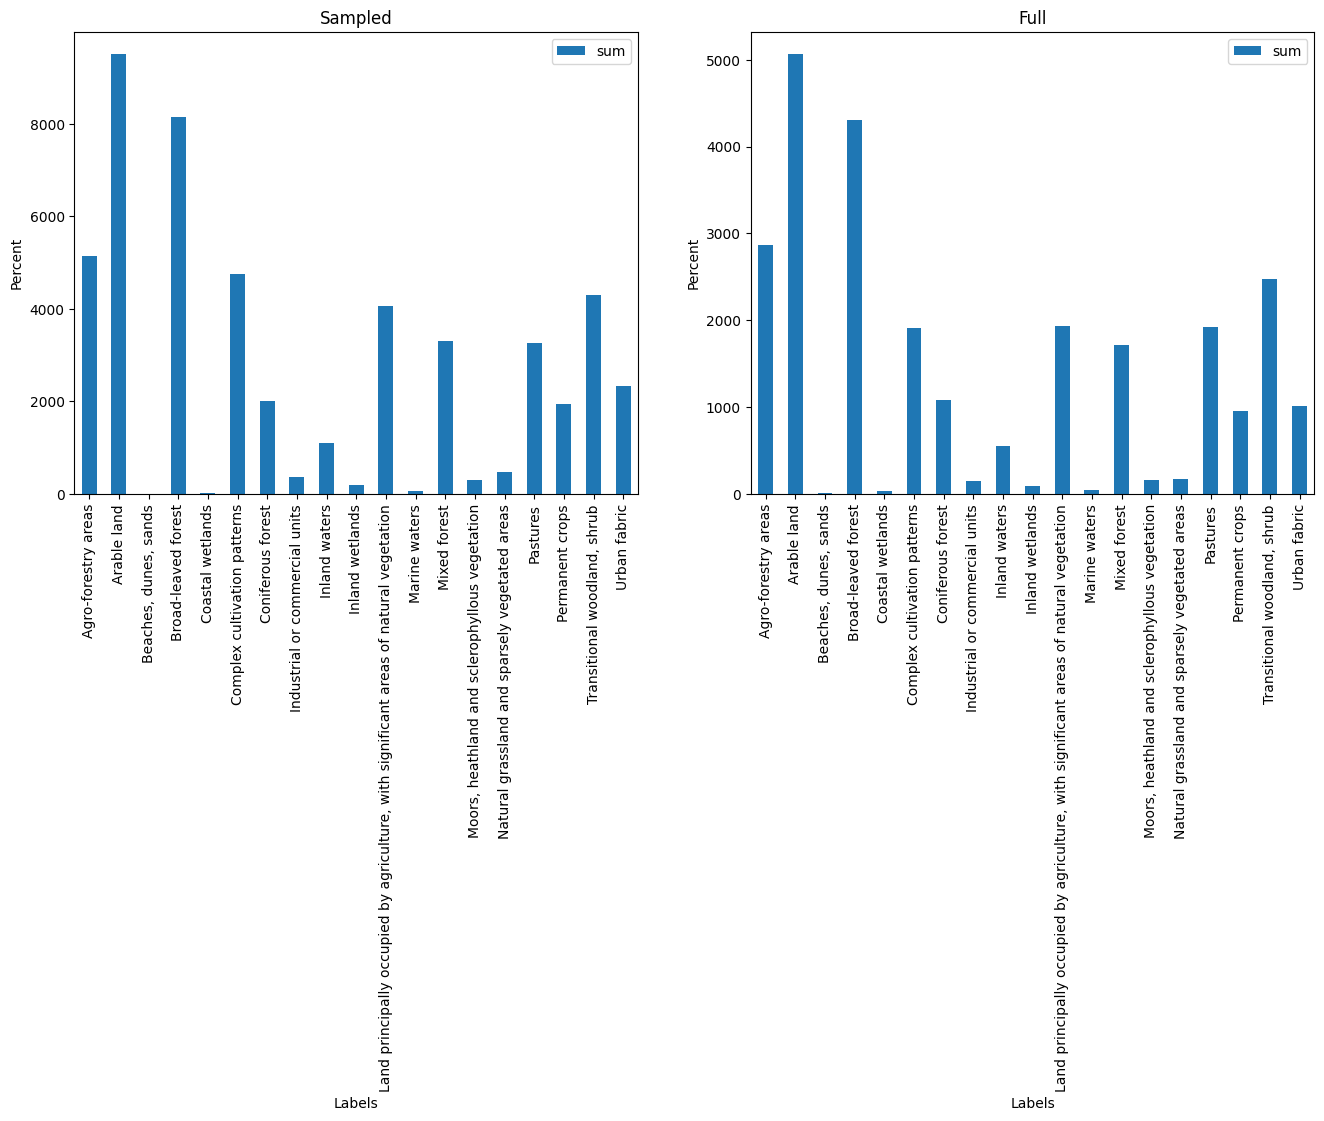

In [14]:
plot_compare(sum_train, sum_val, 'sum')

In [15]:
train_dataset.calculate_unbalanced_df()

2025-08-18 13:15:08.232 | INFO     | src.loader.reader:calculate_unbalanced_df:546 - Value of imbalanced before clip: [2.30188405 1.6855889  8.54352349 1.83935426 7.47881275 2.37852589
 3.23872715 4.91918255 3.84122659 5.58341839 2.53520182 6.65645384
 2.74321945 5.16935478 4.68490126 2.7569329  3.2715501  2.4783439
 3.09334377]
2025-08-18 13:15:08.234 | INFO     | src.loader.reader:calculate_unbalanced_df:551 - Upper and Down limit of clipping: (50, 1)
2025-08-18 13:15:08.235 | WARNING  | src.loader.reader:calculate_unbalanced_df:559 - Unbalanced results: [ 1  1 10  1  8  1  3  5  3  6  2  7  2  5  4  2  3  2  2]


------------------------------------------------------------------------------------------
Agro-forestry areas 1
Arable land 1
Beaches, dunes, sands 10
Broad-leaved forest 1
Coastal wetlands 8
Complex cultivation patterns 1
Coniferous forest 3
Industrial or commercial units 5
Inland waters 3
Inland wetlands 6
Land principally occupied by agriculture, with significant areas of natural vegetation 2
Marine waters 7
Mixed forest 2
Moors, heathland and sclerophyllous vegetation 5
Natural grassland and sparsely vegetated areas 4
Pastures 2
Permanent crops 3
Transitional woodland, shrub 2
Urban fabric 2


tensor([ 1,  1, 10,  1,  8,  1,  3,  5,  3,  6,  2,  7,  2,  5,  4,  2,  3,  2,
         2])

In [16]:
val_dataset.calculate_unbalanced_df()

2025-08-18 13:15:11.889 | INFO     | src.loader.reader:calculate_unbalanced_df:546 - Value of imbalanced before clip: [2.22232153 1.6533849  8.10425019 1.81569485 6.57277382 2.62569678
 3.19435647 5.1664119  3.87924293 5.60898076 2.61427994 6.3995021
 2.73594046 5.13383573 5.05972776 2.62517499 3.31988834 2.3692921
 3.26203355]
2025-08-18 13:15:11.890 | INFO     | src.loader.reader:calculate_unbalanced_df:551 - Upper and Down limit of clipping: (50, 1)
2025-08-18 13:15:11.892 | WARNING  | src.loader.reader:calculate_unbalanced_df:559 - Unbalanced results: [ 1  1 10  1  7  2  3  5  4  6  2  7  2  5  5  2  3  1  3]


------------------------------------------------------------------------------------------
Agro-forestry areas 1
Arable land 1
Beaches, dunes, sands 10
Broad-leaved forest 1
Coastal wetlands 7
Complex cultivation patterns 2
Coniferous forest 3
Industrial or commercial units 5
Inland waters 4
Inland wetlands 6
Land principally occupied by agriculture, with significant areas of natural vegetation 2
Marine waters 7
Mixed forest 2
Moors, heathland and sclerophyllous vegetation 5
Natural grassland and sparsely vegetated areas 5
Pastures 2
Permanent crops 3
Transitional woodland, shrub 1
Urban fabric 3


tensor([ 1,  1, 10,  1,  7,  2,  3,  5,  4,  6,  2,  7,  2,  5,  5,  2,  3,  1,
         3])

In [17]:
def log_strategy_4_sqrt_log_hybrid(imbalance, min_weight=1.0, max_weight=20.0):
    """
    Strategy 4: Square root of log transformation (gentler compression)
    """
    # Apply sqrt(log(x+1)) for very gentle compression
    sqrt_log_weights = np.sqrt(np.log(imbalance + 1))
    
    # Scale to desired range
    min_val = sqrt_log_weights.min()
    max_val = sqrt_log_weights.max()
    
    if max_val > min_val:
        scaled_weights = min_weight + (max_weight - min_val) * (sqrt_log_weights - min_val) / (max_val - min_val)
    else:
        scaled_weights = np.full_like(sqrt_log_weights, (min_weight + max_weight) / 2)
    
    return scaled_weights

In [21]:
import numpy as np
val_imbalanced = np.array([2.22232153, 1.6533849,  8.10425019, 1.81569485, 6.57277382, 2.62569678,
 3.19435647, 5.1664119,  3.87924293, 5.60898076, 2.61427994, 6.3995021,
 2.73594046, 5.13383573, 5.05972776, 2.62517499, 3.31988834, 2.3692921,
 3.26203355])
train_imbalanced = np.array([2.30188405, 1.6855889,  8.54352349, 1.83935426, 7.47881275, 2.37852589,
 3.23872715, 4.91918255 ,3.84122659, 5.58341839, 2.53520182, 6.65645384,
 2.74321945, 5.16935478, 4.68490126 ,2.7569329,  3.2715501,  2.4783439,
 3.09334377])

In [42]:
a=log_strategy_4_sqrt_log_hybrid(val_imbalanced).astype(int)

In [43]:
b=log_strategy_4_sqrt_log_hybrid(train_imbalanced).astype(int)

In [45]:
c = a-b

In [47]:
np.absolute(c).sum()

9

In [61]:
def log_strategy_1_simple_scaling(imbalance, min_weight=1.0, max_weight=20.0):
    """
    Strategy 1: Simple log transformation + scaling to desired range
    """
    # Apply log transformation (add 1 to avoid log(0) issues)
    log_weights = np.log(imbalance + 1)
    
    # Scale to desired range [min_weight, max_weight]
    min_log = log_weights.min()
    max_log = log_weights.max()
    
    if max_log > min_log:
        scaled_weights = min_weight + (max_weight - min_weight) * (log_weights - min_log) / (max_log - min_log)
    else:
        scaled_weights = np.full_like(log_weights, (min_weight + max_weight) / 2)
    
    return scaled_weights

def log_strategy_2_natural_log_offset(imbalance, offset=10.0, scale_factor=2.0):
    """
    Strategy 2: Natural log with offset + scaling factor
    Formula: scale_factor * ln(weight + offset)
    """
    log_weights = scale_factor * np.log(imbalance + offset)
    
    # Ensure minimum weight of 1.0
    log_weights = np.maximum(log_weights, 1.0)
    
    return log_weights

def log_strategy_3_log10_capped(imbalance, cap=15.0):
    """
    Strategy 3: Log10 transformation with capping
    """
    # Use log10 for more moderate compression
    log_weights = np.log10(imbalance + 1)
    
    # Scale to make meaningful weights (multiply by factor)
    log_weights = log_weights * 3.0  # Adjust this factor as needed
    
    # Ensure minimum of 1.0 and cap maximum
    log_weights = np.clip(log_weights, 1.0, cap)
    
    return log_weights

def log_strategy_4_sqrt_log_hybrid(imbalance, min_weight=1.0, max_weight=20.0):
    """
    Strategy 4: Square root of log transformation (gentler compression)
    """
    # Apply sqrt(log(x+1)) for very gentle compression
    sqrt_log_weights = np.sqrt(np.log(imbalance + 1))
    
    # Scale to desired range
    min_val = sqrt_log_weights.min()
    max_val = sqrt_log_weights.max()
    
    if max_val > min_val:
        scaled_weights = min_weight + (max_weight - min_val) * (sqrt_log_weights - min_val) / (max_val - min_val)
    else:
        scaled_weights = np.full_like(sqrt_log_weights, (min_weight + max_weight) / 2)
    
    return scaled_weights

In [59]:
a = log_strategy_1_simple_scaling(train_imbalanced).astype(int)
b = log_strategy_1_simple_scaling(val_imbalanced).astype(int)
c = a-b
np.absolute(c).sum()

12

In [57]:
a = log_strategy_2_natural_log_offset(train_imbalanced).astype(int)
b = log_strategy_2_natural_log_offset(val_imbalanced).astype(int)
c = a-b
np.absolute(c).sum()

0

array([5, 4, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [53]:
a = log_strategy_3_log10_capped(train_imbalanced).astype(int)
b = log_strategy_3_log10_capped(val_imbalanced).astype(int)
c = a-b
np.absolute(c).sum()

0

In [62]:
a = log_strategy_4_sqrt_log_hybrid(train_imbalanced).astype(int)
b = log_strategy_4_sqrt_log_hybrid(val_imbalanced).astype(int)
c = a-b
np.absolute(c).sum()

9

In [63]:
a

array([ 4,  1, 20,  2, 18,  5,  8, 13, 10, 15,  5, 17,  6, 14, 13,  6,  8,
        5,  8])

In [64]:
b

array([ 4,  1, 20,  2, 17,  6,  8, 14, 11, 15,  6, 17,  7, 14, 14,  6,  9,
        5,  9])

In [65]:
c

array([ 0,  0,  0,  0,  1, -1,  0, -1, -1,  0, -1,  0, -1,  0, -1,  0, -1,
        0, -1])

In [70]:
from sklearn.preprocessing import minmax_scale
aa=minmax_scale(a, (1,10)).astype(int)

In [71]:
bb=minmax_scale(b, (1,10)).astype(int)

In [73]:
np.absolute(aa-bb).sum()

5

## Plot validation

In [74]:
def get_batch_n(dataloader, n):
    """Get the nth batch from dataloader"""
    iterator = iter(dataloader)
    for i in range(n + 1):
        batch = next(iterator)
    return batch


In [85]:
rows = int(16/2)
cols = int(16/2)

In [ ]:
row = idx // rows
col = idx % cols

In [90]:
import numpy as np
import matplotlib.pyplot as plt
def get_label_back(array_label):
    idx_to_label= {0: 'Agro-forestry areas',
                    1: 'Arable land',
                    2: 'Beaches, dunes, sands',
                    3: 'Broad-leaved forest',
                    4: 'Coastal wetlands',
                    5: 'Complex cultivation patterns',
                    6: 'Coniferous forest',
                    7: 'Industrial or commercial units',
                    8: 'Inland waters',
                    9: 'Inland wetlands',
                    10: 'Land principally occupied by agriculture, with significant areas of natural vegetation',
                    11: 'Marine waters',
                    12: 'Mixed forest',
                    13: 'Moors, heathland and sclerophyllous vegetation',
                    14: 'Natural grassland and sparsely vegetated areas',
                    15: 'Pastures',
                    16: 'Permanent crops',
                    17: 'Transitional woodland, shrub',
                    18: 'Urban fabric'}
    label_list = []
    for i,pos in enumerate(array_label):
        if int(pos)==1:
            label_list.append(idx_to_label[i])
    return label_list
def plot_batch(batch,ncols=4, figsize=(15, 10)):
    """
    Plot images from a batch with their corresponding labels.
    
    Args:
        batch: Tuple of (images, labels) from dataloader
        num_samples: Number of samples to display (default: 8)
        figsize: Figure size for the plot (default: (15, 10))
    """
    images, labels = batch
    
    rows = int(images.shape[0]/ncols)
    cols = ncols
    num_samples = int(images.shape[0])

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    for idx in range(num_samples):
        row = idx // rows
        col = idx % cols
        ax = axes[row, col]
        
        if idx < len(images):
            # Handle image data
            img = images[idx].numpy()
            
            imgm =  np.transpose(img, (2,1,0))

            # Normalize to 0-1 range for display
            imgm_normalized = (imgm - imgm.min()) / (imgm.max() - imgm.min())

            ax.imshow(imgm_normalized)
            ##ax.imshow(imgm)
            # Get and display labels
            label_array = labels[idx]
            label_names = get_label_back(label_array.numpy())
            
            # Format labels for display
            if len(label_names) > 3:
                title = f"{', '.join(label_names[:4])}\n+ {len(label_names)-4} more"
            else:
                title = ', '.join(label_names)
            
            ax.set_title(title, fontsize=10, wrap=True)
            ax.axis('off')
        else:
            # Hide empty subplots
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [77]:
from torch.utils.data import DataLoader
def loader_dataloader(dataset,**kwargs):
    return DataLoader(
            dataset = dataset,
            **kwargs
        )

In [79]:
val_dl = loader_dataloader(val_dataset,            
                                    batch_size= 16,
                                    shuffle = False,
                                    num_workers = 4,
                                    pin_memory = True)

In [81]:
batch = get_batch_n(val_dl,0)

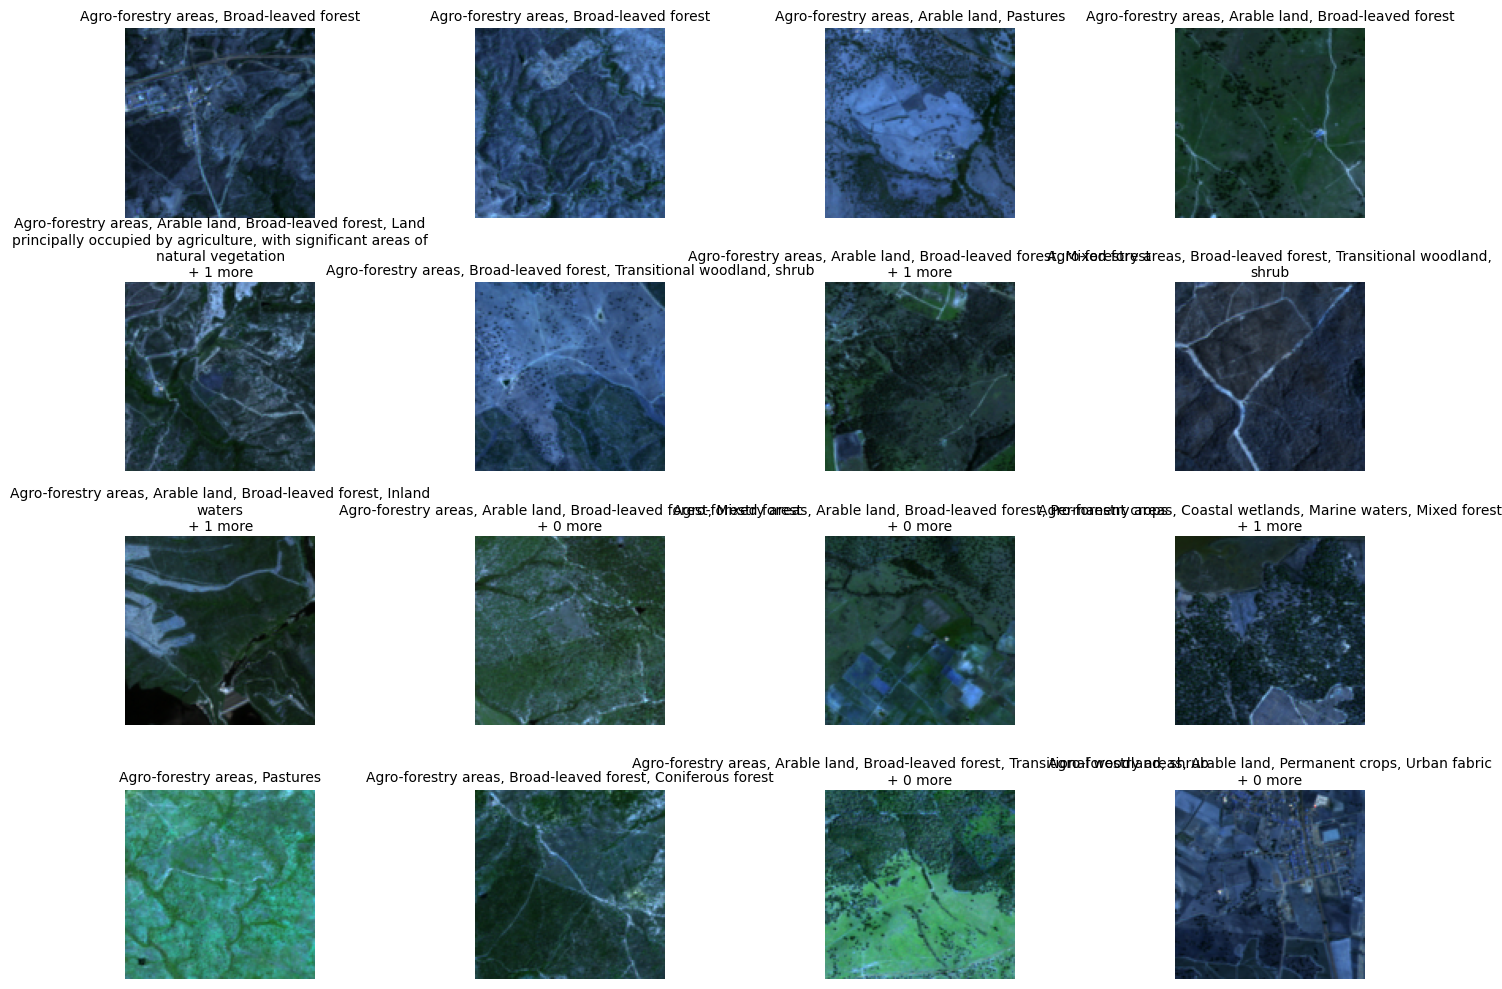

In [91]:
plot_batch(batch)

In [94]:
batch[1].shape

torch.Size([16, 19])

In [97]:
batch[0].shape

torch.Size([16, 3, 120, 120])

In [102]:
batch[0][0][0].mean()

tensor(489.0028)

In [103]:
batch[0][0][1].mean()

tensor(764.5654)

In [104]:
batch[0][0][2].mean()

tensor(1043.9801)

In [105]:
val_dataset.__getitem__(0)

(tensor([[[ 188.,  148.,  120.,  ...,  555.,  565.,  622.],
          [ 283.,  248.,  197.,  ...,  642.,  650.,  634.],
          [ 304.,  251.,  267.,  ...,  675.,  709.,  677.],
          ...,
          [ 122.,  118.,  128.,  ...,  354.,  338.,  352.],
          [  84.,  106.,  277.,  ...,  361.,  348.,  407.],
          [  76.,  139.,  276.,  ...,  341.,  441.,  415.]],
 
         [[ 449.,  382.,  401.,  ...,  835.,  901.,  885.],
          [ 549.,  483.,  422.,  ...,  928.,  932.,  990.],
          [ 499.,  573.,  476.,  ...,  963.,  991.,  995.],
          ...,
          [ 345.,  275.,  356.,  ...,  594.,  569.,  626.],
          [ 345.,  297.,  538.,  ...,  572.,  619.,  672.],
          [ 297.,  334.,  477.,  ...,  583.,  713.,  713.]],
 
         [[ 423.,  362.,  305.,  ..., 1276., 1274., 1482.],
          [ 610.,  511.,  395.,  ..., 1400., 1396., 1472.],
          [ 641.,  539.,  579.,  ..., 1428., 1560., 1486.],
          ...,
          [ 338.,  249.,  390.,  ...,  825.,  841